# Experiment 11
# Breast Cancer Classification Using CUDA (RAPIDS cuML)


## Aim
To implement GPU accelerated breast cancer classification using CUDA libraries.


## Theory
Breast cancer classification using RAPIDS cuDF/cuML running on NVIDIA GPUs.


In [1]:
!nvidia-smi

Mon Jun  1 10:03:03 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import cudf
import cupy as cp
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from cuml.model_selection import train_test_split
from cuml.ensemble import RandomForestClassifier
from cuml.metrics import accuracy_score

In [3]:
data=load_breast_cancer()
X=cudf.DataFrame(data.data,columns=data.feature_names)
y=cudf.Series(data.target)
print(X.shape)
X.head()

(569, 30)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [4]:
y.value_counts()

1    357
0    212
Name: count, dtype: int64

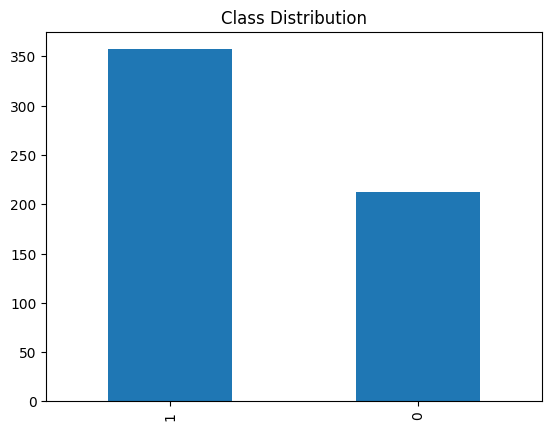

In [5]:
y.value_counts().to_pandas().plot(kind='bar')
plt.title('Class Distribution')
plt.show()

## Train Test Split

In [6]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

## GPU Model Training

In [7]:
import time
start=time.time()
model=RandomForestClassifier(n_estimators=200,max_depth=12,random_state=42)
model.fit(X_train,y_train)
pred=model.predict(X_test)
gpu_time=time.time()-start
print('GPU Time:',gpu_time)

GPU Time: 4.68588662147522


In [8]:
acc=accuracy_score(y_test,pred)
print('Accuracy =',float(acc)*100)

Accuracy = 96.49122807017544


In [9]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test.to_pandas(),pred.to_pandas())
print(cm)

[[40  3]
 [ 1 70]]


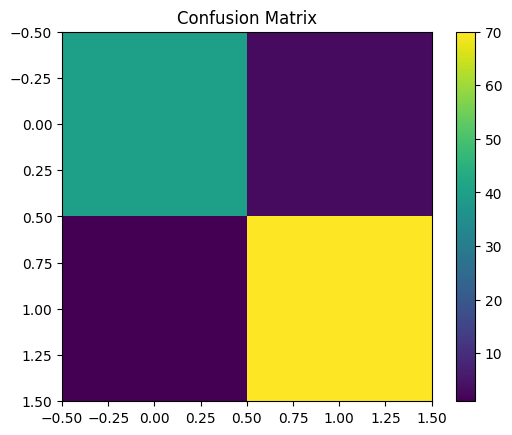

In [10]:
plt.imshow(cm)
plt.colorbar()
plt.title('Confusion Matrix')
plt.show()

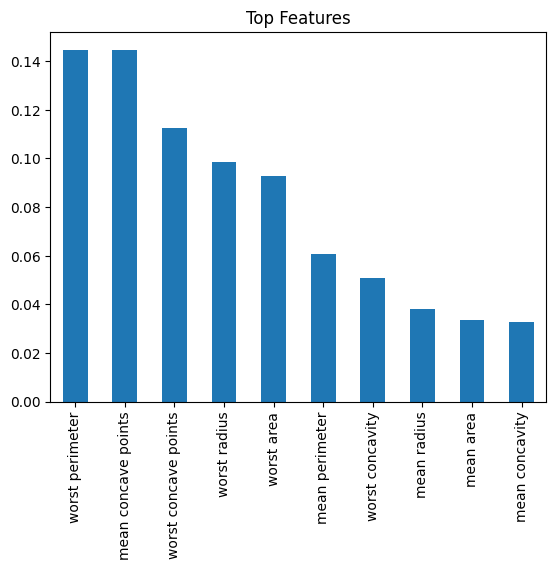

In [12]:
import pandas as pd

fi = pd.Series(
    model.feature_importances_,
    index=X_train.columns
)

fi.sort_values(ascending=False).head(10).plot(kind='bar')
plt.title('Top Features')
plt.show()

## Result
GPU accelerated classification completed successfully with high accuracy.
